In [12]:
!pip install pandas scikit-learn nltk matplotlib

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import time

nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

True

In [2]:
file_path = 'News_Category_Dataset_v3.json'
df = pd.read_json('/content/News_Category_Dataset_v3.json', lines=True)
df['text'] = df['headline'] + " " + df['short_description']
df = df[['category', 'text']]

###Visualization of dataset
Issue #1

In [3]:
counts = df['category'].value_counts()
X_plot = counts.index.tolist()
Y_plot = counts.values.tolist()

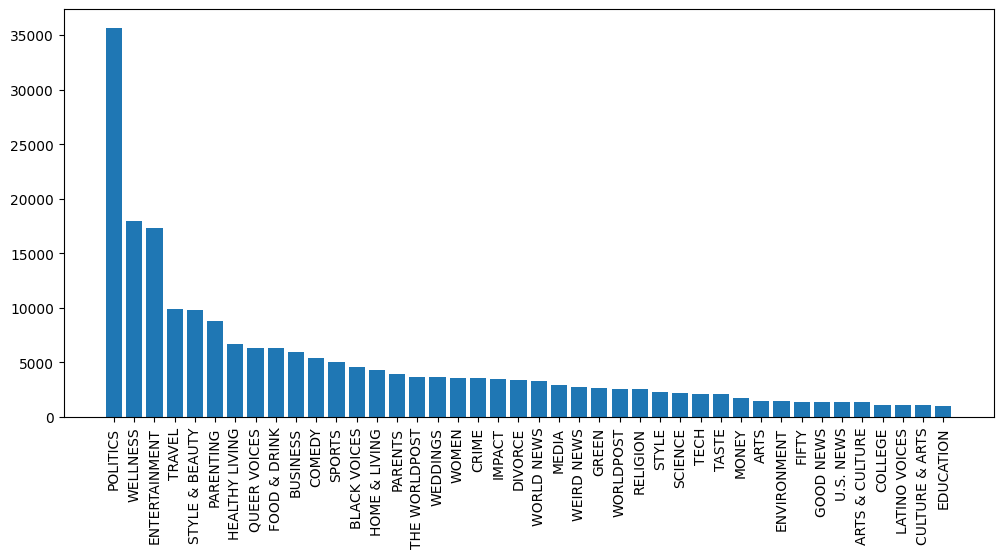

In [4]:
plt.figure(figsize=(12,6))
plt.bar(X_plot,Y_plot)
plt.xticks(rotation=90)
plt.subplots_adjust(bottom=0.2)

###Text preprocessing
Issue #3

In [5]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(text.lower())
    tokens = [token for token in tokens if token.isalpha() and token not in stop_words]
    Ltokens = [lemmatizer.lemmatize(token) for token in tokens]
    return ' '.join(Ltokens)

df['processed_text'] = df['text'].apply(preprocess_text)

In [ ]:
#df.to_csv("df.csv")

###Merging of classes
Issue #2

merged classes inorder to better accuracy based on confusion matrix and dataset visualisation while still keeping the relevancy. For now it is a hardcoded method cause didn't find any other way, but trying to see solutions that automate.

In [7]:
new_categories = {
    'STYLE':'STYLE & BEAUTY',
    'PARENTS':'PARENTING',
    'ARTS':'ARTS & CULTURE',
    'BLACK VOICES':'IDENTITY',
    'COLLEGE':'EDUCATION',
    'CULTURE & ARTS':'ARTS & CULTURE',
    'GREEN':'ENVIRONMENT',
    'LATINO VOICES':'IDENTITY',
    'QUEER VOICES':'IDENTITY',
    'TASTE':'FOOD & DRINK',
    'WORLDPOST':'THE WORLDPOST'
}
df['category']=df['category'].replace(new_categories)

###Splitting data set
Issue #4

In [8]:
X_train, X_test, y_train, y_test = train_test_split(df['processed_text'], df['category'], test_size=0.2,random_state=True)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('classifier', BernoulliNB()),
])

###Training & Testing

In [9]:
print("Training the model...")
start_time = time.time()
pipeline.fit(X_train, y_train)
end_time = time.time()
training_time = end_time - start_time
print(f"Training completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

print("Making predictions...")
y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=1))

Training the model...
Training completed in 4.80 seconds (0.08 minutes)
Making predictions...
Accuracy: 0.5831

Classification Report:
                precision    recall  f1-score   support

ARTS & CULTURE       0.42      0.39      0.40       754
      BUSINESS       0.44      0.42      0.43      1199
        COMEDY       0.44      0.47      0.45      1077
         CRIME       0.40      0.68      0.50       720
       DIVORCE       0.70      0.66      0.68       688
     EDUCATION       0.40      0.41      0.40       425
 ENTERTAINMENT       0.53      0.68      0.59      3435
   ENVIRONMENT       0.44      0.41      0.42       818
         FIFTY       0.17      0.17      0.17       244
  FOOD & DRINK       0.61      0.80      0.69      1733
     GOOD NEWS       0.30      0.19      0.23       270
HEALTHY LIVING       0.33      0.27      0.29      1304
 HOME & LIVING       0.68      0.64      0.66       814
      IDENTITY       0.58      0.42      0.49      2375
        IMPACT       0.3

###Confusion Matrix
Issue #6


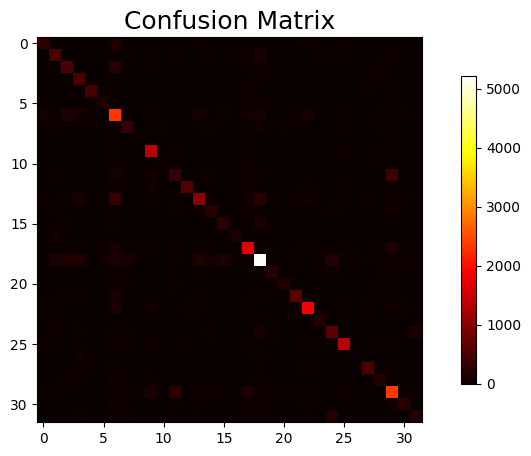

In [11]:
plt.figure(figsize=(10, 5))
plt.imshow(confusion_matrix(y_test, y_pred), interpolation='nearest', cmap='hot')
plt.title('Confusion Matrix', fontsize=18)
plt.colorbar(shrink=0.8)
plt.show()